# Actividad. Perceptrón de para obtener la relación velocidad - altura

<table>
    <head>  
        <tr>
			<th colspan="2">Caracteristicas</th>
			<th>Resultado Esperado</th>
        </tr> 
        <tr>
			<th>Altura</th>
			<th>velocidad</th>
			<th>Aceleración</th>
        </tr>
    </head>
    <body>  
        <tr>
			<td style="text-align:center">0</td>
			<td style="text-align:center">0</td>
			<td style="text-align:center">350</td>
        </tr>
        <tr>
			<td style="text-align:center">0</td>
			<td style="text-align:center">1</td>
			<td style="text-align:center">200</td>
        </tr>
        <tr>
			<td style="text-align:center">1</td>
			<td style="text-align:center">0</td>
			<td style="text-align:center">200</td>
        </tr>
        <tr>
			<td style="text-align:center">1</td>
			<td style="text-align:center">1</td>
			<td style="text-align:center">50</td>
        </tr>
    </body>
</table>

In [2]:
# Definiendo la función a utilizar en el perceptrón

# Importando las librerías a utilizar
import numpy as np

# Definición de la función Relu
#   La salida es el máximo entre 0 y la suma ponderada
def relu( sumaPonderada ):
    return max( 0, sumaPonderada )


===== ÉPOCA 1 =====
x1  x2   target   salida   error
0   0      350        [0.24439669]        [349.75560331]
0   1      200        [315.27670832]        [-115.27670832]
1   0      200        [212.23489468]        [-12.23489468]
1   1      50        [86.71531542]        [-36.71531542]
Errores totales en la época: [513.98252173]
Pesos Finales: [ -43.09569658 -136.54055271]
Bias Finales: [167.22021309]

===== ÉPOCA 2 =====
x1  x2   target   salida   error
0   0      350        [167.22021309]        [182.77978691]
0   1      200        [195.1814686]        [4.8185314]
1   0      200        [292.96300299]        [-92.96300299]
1   1      50        0        50
Errores totales en la época: [330.5613213]
Pesos Finales: [-81.76239927 -87.20387445]
Bias Finales: [297.39199688]

===== ÉPOCA 3 =====
x1  x2   target   salida   error
0   0      350        [297.39199688]        [52.60800312]
0   1      200        [257.53532524]        [-57.53532524]
1   0      200        [211.1950077]        [-11.1

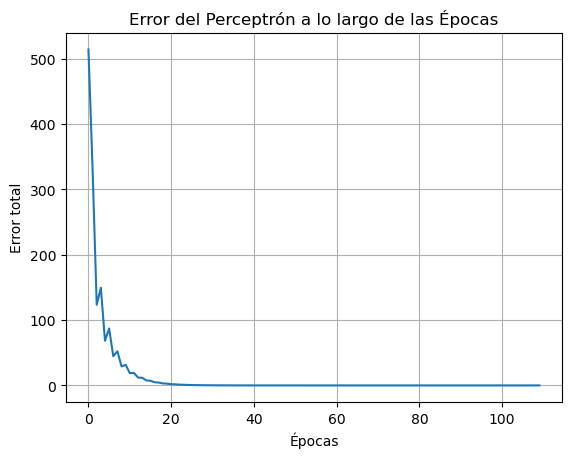

In [3]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Definición de las entradas de la tabla de verdad
entradas = np.array( [ [ 0, 0 ], [ 0, 1 ], [ 1, 0 ], [ 1, 1 ] ] )

# Definión de los resultados esperados del procesamiento de la información por el perceptrón
resultadoEsperado = np.array( [ 350, 200, 200, 50 ] )

# Definición de los pesos y el bias iniciales
pesos = np.random.rand(2)
bias = np.random.rand(1)

# Definición del learning_rate y las epocas
learning_rate = 0.9
epocas = 110

# Inicializando los arreglos donde se almacenaran los valores y las epocas correspondientes
errores_x_epoca = []
epocas_tiempo = []

# Entrenamiento del perceptrón
for epoca in range(epocas):
    
    error_epoca = 0
    
    # Se imprime el cabecero de la información por epoca
    print(f"\n===== ÉPOCA { epoca + 1 } =====")
    print("x1  x2   target   salida   error")

    for i in range(len(entradas)):
        
        # Obteniendo el valor de las entradas y el valor esperado 
        x = entradas[ i ]
        resultado_esperado = resultadoEsperado[ i ]
        
        # Cálculo de la suma ponderada
        sumaPonderada = np.dot(entradas[i], pesos) + bias
        
        # Cálculo de la salida utilizando la función Relu
        salida = relu(sumaPonderada)
        
        # Cálculo del error
        error = resultadoEsperado[i] - salida
        
        # Actualización de los pesos y el bias utilizando la regla de aprendizaje del perceptrón
        pesos = pesos + learning_rate * error * entradas[i]
        bias = bias + learning_rate * error
        # Imprimiendo los valores obtenidos con los esperados
        print(f"{ x[ 0 ]}   { x[ 1 ] }      { resultado_esperado }        { salida }        { error }")
        # Acumulación del error para la época actual
        error_epoca += abs(error)
        
    print(f'Errores totales en la época: { error_epoca }')
    print(f'Pesos Finales: { pesos }')
    print(f'Bias Finales: { bias }')
    # Almacenamiento del error total de la época y el número de época
    errores_x_epoca.append(error_epoca)
    epocas_tiempo.append(epoca)
# Visualización del error a lo largo de las épocas
plt.plot(epocas_tiempo, errores_x_epoca)
plt.xlabel('Épocas')
plt.ylabel('Error total')
plt.title('Error del Perceptrón a lo largo de las Épocas')
plt.grid()
plt.show()



## Utilizando la librería SKLearn

<b>Nota:</b> El uso de un perceptrón no con la librería sklearn, no resuelve el problema de manera adecuada debido a que hace uso de 3 pesos y 2 bias. Esto debido a que las salidas "no son binarias". Ademas que la tabla de verdad podemos compararla con la de la compuerta XOR donde los valores 0, 1 y 1, 0 poseen un valor unico, mientras que las entradas restantes tienen valores diferentes. Incluso en una implementación manual como en la anterior, no llegamos a los valores exactos sin importar el número de epocas que mandemos a llamar siempre habrá un marguen pequeño de error.



Pesos Iniciales
Weights: [[ 0.   0. ]
 [ 0.   0. ]
 [-0.5 -0.5]]
Bias: [-0.5  0.   0. ]

Época 1
Predicciones: [300 250 250 250]
Error: 1
Weights: [[ 0.   0. ]
 [ 0.   0. ]
 [-0.5 -0.5]]
Bias: [-1.   0.   0.5]

Época 2
Predicciones: [300 250 250 250]
Error: 1
Weights: [[ 0.5  0. ]
 [ 0.   0. ]
 [-0.5 -1. ]]
Bias: [-1.   0.   0.5]

Época 3
Predicciones: [300 250 250 250]
Error: 1
Weights: [[ 0.5  0. ]
 [ 0.   0. ]
 [-1.  -1. ]]
Bias: [-1.5  0.   0.5]

Época 4
Predicciones: [300 250 250 250]
Error: 1
Weights: [[ 0.5  0.5]
 [ 0.   0. ]
 [-1.  -1. ]]
Bias: [-1.5  0.   0.5]

Época 5
Predicciones: [300 250 250  50]
Error: 0
Weights: [[ 1.   0.5]
 [ 0.   0. ]
 [-1.  -1. ]]
Bias: [-1.5  0.   0.5]

Época 6
Predicciones: [300 250 250 250]
Error: 1
Weights: [[ 1.   0.5]
 [ 0.   0. ]
 [-1.  -1. ]]
Bias: [-2.   0.   0.5]

Época 7
Predicciones: [300 250 250  50]
Error: 0
Weights: [[ 1.  1.]
 [ 0.  0.]
 [-1. -1.]]
Bias: [-2.   0.   0.5]

Época 8
Predicciones: [300 250 250  50]
Error: 0
Weights: [[ 1

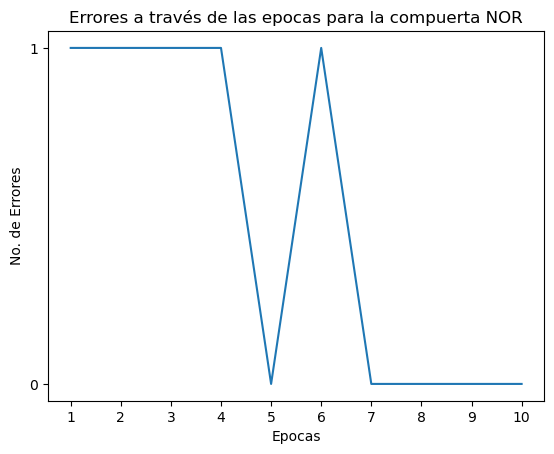

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
%matplotlib inline

# Definición de las entradas de la tabla de verdad
entradas = np.array( [ [ 0, 0 ], [ 0, 1 ], [ 1, 0 ], [ 1, 1 ] ] )

# Definión de los resultados esperados del procesamiento de la información por el perceptrón
resultadoEsperado = np.array( [ 300, 250, 250, 50 ] )

# Definiendo el perceptron que realizará los cálculos de la compuerta
modelo = Perceptron(eta0=0.5, max_iter=1, warm_start=True)

# Definición de las epocas
epocas = 10

# Inicializando los arreglos donde se almacenaran los valores y las epocas correspondientes
errores_x_epoca = []
epocas_tiempo = []

#Entrenando la 1er vez el perceptrón, para obtener los valores iniciales
modelo.partial_fit(entradas, resultadoEsperado, classes=np.array([300, 250, 50]))

#Imprimiendo los valores iniciales
print("\nPesos Iniciales")
print("Weights:", modelo.coef_)
print("Bias:", modelo.intercept_)

# Iterando sobre x número de épocas
for epoca in range(epocas):

    # Entrenando el modelo por época
    modelo.partial_fit(entradas, resultadoEsperado )

    # Obteniendo las predicciones
    predicciones = modelo.predict(entradas)

    # Obteniendo los errores
    error = np.sum(predicciones != resultadoEsperado)
    errores_x_epoca.append(error)

    # Añadiendo la época correspondiente
    epocas_tiempo.append( epoca + 1)

    # Imprimiendo los valores obtenidos por cada época
    print(f"\nÉpoca {epoca+1}")
    print("Predicciones:", predicciones)
    print("Error:", error)
    print("Weights:", modelo.coef_)
    print("Bias:", modelo.intercept_)

# Imprimiendo los valores finales obtenidos
print("\nPesos Finales")
print("Weights:", modelo.coef_)
print("Bias:", modelo.intercept_)

# Procediendo a a graficar los valores de errores totales por épocas
plt.plot( epocas_tiempo, errores_x_epoca )
plt.title('Errores a través de las epocas para la compuerta NOR')
plt.ylabel('No. de Errores')
plt.xlabel('Epocas')
plt.xticks( range(1, np.max( epocas_tiempo ) + 1 ) )
plt.yticks(range(0, np.max( errores_x_epoca ) + 1 ) )
plt.autoscale(True)
plt.show()